# smsdk Example 2 — KPIs

Listing KPIs, finding which KPIs apply to a given asset, and pulling KPI values over time via the data-visualization API.

For full method signatures and parameter reference, see [docs/README.md](../docs/README.md#kpis).

**Updated:** April 2026 — replaces the former `KPI Examples.ipynb`.

## Setup

In [11]:
from smsdk import client
import pandas as pd
import os

In [ ]:
# Set before running this notebook.
tenant = "demo-bottling"
api_key = ""
api_secret = ""

In [13]:
cli = client.Client(tenant)
success = cli.login('apikey', key_id=api_key, secret_id=api_secret)
assert success, 'SDK login failed — check tenant / API key / secret.'

## List all available KPIs

`get_kpis()` returns every KPI defined on the tenant, regardless of asset.

In [14]:
kpis_dict = cli.get_kpis()
df_kpis = pd.DataFrame(kpis_dict)
print(f'Total KPIs: {len(df_kpis)}')
df_kpis.head()

Total KPIs: 16


,name,unit,formula,rollups,field_maps,dependencies,display_name,bad_threshold,directionality,good_threshold
0,availability,%,(up_time/all_time)*100,"{'line': {}, 'factory': {'ETL3_sanfrancisco': ...","[{'alias_map': {'up_time': {'row_formula': ""if...","[{'name': 'up_time', 'aggregate': 'sum'}, {'na...",Availability,60,positive,80
1,Line Efficiency,%,(prod/target)*100,"{'line': {}, 'factory': {'ETL3_sanfrancisco': ...",[{'alias_map': {'prod': {'name': 'stats__Total...,"[{'name': 'prod', 'aggregate': 'sum'}, {'name'...",Line Efficiency,60,positive,80
2,MTBF,minutes,MTBF,"{'line': {}, 'factory': {'ETL3_sanfrancisco': ...",[{'alias_map': {'MTBF': {'name': 'stats__MTBF_...,"[{'name': 'MTBF', 'aggregate': 'avg'}]",MTBF,5,positive,10
3,rejectrate,%,((rejectsl1 + rejectsl2) / (throughputl1 + thr...,"{'line': {}, 'factory': {'ETL3_sanfrancisco': ...",[{'alias_map': {'rejectsl1': {'name': 'stats__...,"[{'name': 'rejectsl1', 'aggregate': 'sum'}, {'...",Reject Rate,10,negative,5
4,percentage_of_time_in_micro_stops,%,((Duration_Rejects/Record_Duration)*100) if (R...,"{'line': {}, 'factory': {}}",[{'alias_map': {'Record_Duration': {'name': 's...,"[{'name': 'Record_Duration', 'aggregate': 'sum...",% Micro Stops,40,negative,20


## List KPIs available for a specific asset

`get_kpis_for_asset(asset_selection=...)` narrows the list to KPIs actually configured for a given machine type or a specific machine.

> **Note:** `asset_selection` expects the **raw machine-type name** (system name), not the UI display name. The SDK's `get_kpis_for_asset` will attempt to translate a display name, but using the raw name is safer — see the helper below.

For details on the `asset_selection` object, see [docs/README.md — Common Query Parameters](../docs/README.md#common-query-parameters).

In [15]:
# Helper: display name -> raw machine type
def get_raw_machine_type(clean_machine_type: str) -> str:
    machines = cli.get_machine_names(source_type=clean_machine_type)
    return cli.get_type_from_machine(machines[0])

# Pick a machine type that exists on your tenant (adjust as needed)
clean_type = cli.get_machine_type_names()[0]
print(f'Using machine type: {clean_type}')

Using machine type: Packer


In [16]:
# KPIs available for all machines of a given type
asset_selection = {
    'asset_selection': {
        'machine_type': [get_raw_machine_type(clean_type)],
    },
}
kpis_for_type = cli.get_kpis_for_asset(**asset_selection)
pd.DataFrame(kpis_for_type)

,name,display_name,unit,type,data_type,stream_types,raw_data_field,model
0,availability,Availability,%,continuous,float,[],,kpi


In [17]:
# KPIs available for one specific machine
machines = cli.get_machine_names(source_type=clean_type)
asset_selection = {
    'asset_selection': {
        'machine_type': [get_raw_machine_type(clean_type)],
        'machine_source': [machines[0]],
    },
}
kpis_for_machine = cli.get_kpis_for_asset(**asset_selection)
pd.DataFrame(kpis_for_machine)

,name,display_name,unit,type,data_type,stream_types,raw_data_field,model
0,availability,Availability,%,continuous,float,[],,kpi


## KPI values over time (`get_kpi_data_viz`)

`get_kpi_data_viz` is the programmatic equivalent of a Data Viz chart in MA. You specify:
- **`machine_sources`** — list of machine names
- **`kpis`** — list of KPI names (averaged by default)
- **`i_vars`** — independent variables (typically one time field with a resolution)
- **`time_selection`** — relative or absolute time window

See [docs/README.md — KPIs](../docs/README.md#kpis) for the full parameter schema.

### Query settings (edit me)

In [18]:
this_machine_sources = [machines[0]]

# IMPORTANT: only pass KPIs that are actually configured for this machine's type.
# Passing every tenant-level KPI will error out on the first one without a field_map
# for this machine type (e.g. "Line Efficiency" isn't configured for a Packer).
# `kpis_for_machine` was computed in the prior cell from cli.get_kpis_for_asset().
this_kpis = [k['name'] for k in kpis_for_machine]
print(f'KPIs to query: {this_kpis}')

# Time resolution: year | quarter | month | week | day | hour | minute | second
this_i_vars = [
    {
        'name': 'endtime',
        'time_resolution': 'day',
        'query_tz': 'America/Los_Angeles',
        'output_tz': 'America/Los_Angeles',
        'bin_strategy': 'user_defined2',
        'bin_count': 50,
    },
]

# Relative time window (last N units). Swap to absolute below if you want a fixed range.
this_time_selection = {
    'time_type': 'relative',
    'relative_start': 1,
    'relative_unit': 'year',
    'ctime_tz': 'America/Los_Angeles',
}

# Alternative: absolute window
# this_time_selection = {
#     'time_type': 'absolute',
#     'start_time': '2023-02-23T08:00:00.000Z',
#     'end_time': '2023-03-01T21:35:35.499Z',
#     'time_zone': 'America/Los_Angeles',
# }

KPIs to query: ['availability']


In [19]:
data_dict = cli.get_kpi_data_viz(
    machine_sources=this_machine_sources,
    kpis=this_kpis,
    i_vars=this_i_vars,
    time_selection=this_time_selection,
)

print(f'Points returned: {len(data_dict)}')
if data_dict:
    data_dict[0]

Points returned: 103


### Turn the nested response into a flat DataFrame
Each returned point has `i_vals` (independent-variable bin info), `d_vals` (KPI aggregates), and `kpi_dependencies` (raw tags feeding the KPI). Flatten to one row per time bin for plotting.

In [20]:
rows = []
for point in data_dict:
    row = {'endtime': point['i_vals']['endtime']['bin_avg']}
    for kpi_name, vals in point['d_vals'].items():
        row[kpi_name] = vals['avg']
    for kpi, deps in point['kpi_dependencies'].items():
        for field, value in deps.items():
            row[field] = value
    rows.append(row)

df_trend = pd.DataFrame(rows)
if not df_trend.empty:
    # bin_avg may come back as unix ms OR as ISO timestamps with mixed offsets,
    # depending on time_resolution / output_tz — let pandas infer and normalize to UTC.
    df_trend['endtime'] = pd.to_datetime(df_trend['endtime'], utc=True)
    df_trend = df_trend.sort_values('endtime').reset_index(drop=True)
df_trend.head()

,endtime,availability,up_time,all_time
0,2026-01-01 08:00:00+00:00,76.486174,66107000.0,86430000.0
1,2026-01-02 08:00:00+00:00,84.761497,73228000.0,86393000.0
2,2026-01-03 08:00:00+00:00,82.515913,71302000.0,86410000.0
3,2026-01-04 08:00:00+00:00,76.843933,66397000.0,86405000.0
4,2026-01-05 08:00:00+00:00,78.527352,67828000.0,86375000.0


### Quick trend plot
Plots the first numeric KPI column from the flattened table, if any data came back.

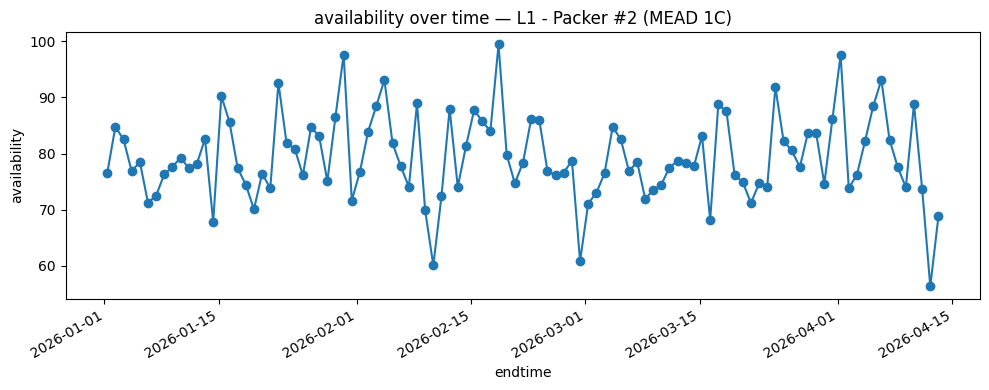

In [21]:
import matplotlib.pyplot as plt

if not df_trend.empty:
    numeric_cols = [c for c in df_trend.columns if c != 'endtime' and pd.api.types.is_numeric_dtype(df_trend[c])]
    if numeric_cols:
        first_kpi = numeric_cols[0]
        fig, ax = plt.subplots(figsize=(10, 4))
        df_trend.plot(x='endtime', y=first_kpi, ax=ax, marker='o', legend=False)
        ax.set_title(f'{first_kpi} over time — {this_machine_sources[0]}')
        ax.set_ylabel(first_kpi)
        plt.tight_layout()
        plt.show()
    else:
        print('No numeric KPI columns in the flattened table.')
else:
    print('No KPI data returned — try widening time_selection or check asset name.')

### Filtering with `where`
`get_kpi_data_viz` also accepts a `where` list to filter the underlying records, same shape as MA's Data Viz filter.

In [22]:
# Example filter — adapt field name / value to your tenant
# where_args = {'where': [{'name': 'oee', 'op': 'gte', 'value': 50}]}
where_args = {'where': []}

filtered = cli.get_kpi_data_viz(
    machine_sources=this_machine_sources,
    kpis=this_kpis,
    i_vars=this_i_vars,
    time_selection=this_time_selection,
    **where_args,
)
print(f'Points returned with filter: {len(filtered)}')

Points returned with filter: 103
